In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Although Model 1 gave a higher rain probability, it used precipprob, which is directly related to rainfall. Therefore, Model 2 was selected as the final model because it predicts rainfall using independent weather features such as humidity, temperature, pressure, cloud cover, windspeed, visibility, solar radiation, and UV index.

In [62]:
df=pd.read_csv("kathmandu_weather_2015 to 2025.csv")
df.head()

,datetime,tempmax,tempmin,temp,dew,humidity,precipprob,precipcover,preciptype,windgust,...,sealevelpressure,cloudcover,visibility,solarradiation,solarenergy,uvindex,severerisk,sunrise,sunset,precipitation
0,2015-01-01,60.7,39.1,50.0,41.7,74.7,100,4.17,rain,11.2,...,1020.4,79.1,2.4,96.6,8.3,4,NaN,2015-01-01T06:54:15,2015-01-01T17:19:31,0.8
1,2015-01-02,71.0,49.9,54.9,48.4,80.1,100,20.83,rain,19.9,...,1022.2,93.3,2.9,40.4,3.3,2,NaN,2015-01-02T06:54:31,2015-01-02T17:20:12,0.0
2,2015-01-03,67.7,48.1,54.8,50.5,86.3,100,8.33,rain,15.4,...,1021.0,90.3,2.8,58.6,5.0,4,NaN,2015-01-03T06:54:46,2015-01-03T17:20:54,0.5
3,2015-01-04,69.9,48.1,54.5,49.6,85.5,100,4.17,rain,17.0,...,1018.1,67.1,2.7,118.0,10.3,6,NaN,2015-01-04T06:54:58,2015-01-04T17:21:37,0.5
4,2015-01-05,64.3,42.7,51.3,45.7,83.2,0,0.00,NaN,16.3,...,1013.9,41.6,3.9,139.2,12.0,6,NaN,2015-01-05T06:55:10,2015-01-05T17:22:20,0.0


In [63]:
df.columns

Index(['datetime', 'tempmax', 'tempmin', 'temp', 'dew', 'humidity',
       'precipprob', 'precipcover', 'preciptype', 'windgust', 'windspeed',
       'winddir', 'sealevelpressure', 'cloudcover', 'visibility',
       'solarradiation', 'solarenergy', 'uvindex', 'severerisk', 'sunrise',
       'sunset', 'precipitation'],
      dtype='object')

In [64]:
df=df.drop(['severerisk','preciptype','solarenergy','precipcover','winddir','sunrise',
       'sunset', 'dew'],axis=1)

In [65]:
cols=["tempmax","tempmin","temp"]
for col in cols:
    df[col]=(df[col]- 32)* 5/9

In [66]:
df.rename(columns={"tempmax":"max_temp_C",
       "tempmin":"min_temp_C",
        "temp":"avg_temp_c",
        },inplace=True)

In [67]:
df["datetime"]=pd.to_datetime(df["datetime"])
df["year"]=df["datetime"].dt.year
df["month"]=df["datetime"].dt.month

df.insert(0,"year",df.pop("year"))
df.insert(1,"month",df.pop("month"))


In [68]:
df.drop('datetime',axis=1,inplace=True)

In [69]:
df['month']=pd.to_datetime(df["month"],format="%m").dt.month_name()




In [70]:
month_order=["January", "February", "March", "April", "May", "June", "July", "August", "September", "October", "November", "December"]
df["month"]=pd.Categorical(df["month"],categories=month_order, ordered=True)

In [77]:
month_map={"January":1, "February":2, "March":3, "April":4, "May":5, "June":6, 
           "July":7, "August":8, "September":9, "October":10, "November":11, "December":12}
df["month"]=df["month"].map(month_map)

In [78]:
df["rain"] = (df["precipitation"] > 0).astype(int)

In [79]:
X=df.drop(columns=["rain","precipitation","precipprob"])
y=df["rain"]

In [80]:

print(X.shape)
print(y.shape)

(3468, 13)
(3468,)


In [81]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,random_state=42,test_size=0.2)

In [82]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [83]:
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)


In [ ]:

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier, 
                              AdaBoostClassifier, ExtraTreesClassifier)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, 
                           roc_auc_score, roc_curve, confusion_matrix, classification_report,
                           mean_squared_error, mean_absolute_error, r2_score)
from sklearn.model_selection import train_test_split, KFold ,cross_val_score

C:\Users\acer\AppData\Local\Temp\ipykernel_28080\769685700.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(results,labels= models.keys())


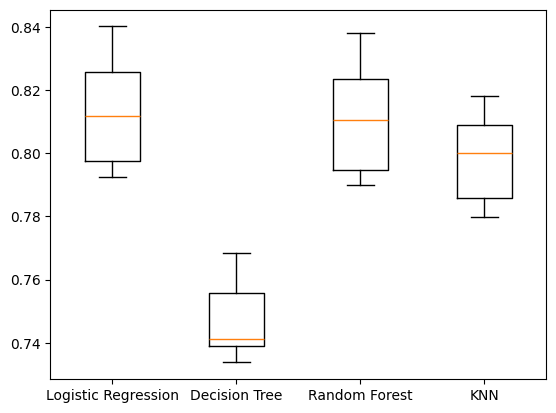

In [ ]:
models={'Logistic Regression':LogisticRegression(max_iter=100),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100,random_state=42),
    'KNN':KNeighborsClassifier(n_neighbors=6)}

results=[]

for model in models.values():
    kf = KFold(n_splits=6, random_state=42, shuffle=True)
    cv_results = cross_val_score(model, X_train_scaled, y_train, cv=kf)
    results.append(cv_results)

plt.boxplot(results,labels= models.keys())
plt.show()

In [ ]:
for name,model in models.items():
    model.fit(X_train_scaled,y_train)
    test_score=model.score(X_test_scaled,y_test)
    print("{} Test Set Accuracy:{}".format(name,test_score))

Logistic Regression Test Set Accuracy:0.8112391930835735
Decision Tree Test Set Accuracy:0.7694524495677233
Random Forest Test Set Accuracy:0.829971181556196
KNN Test Set Accuracy:0.8386167146974063


In [ ]:
for name,model in models.items():
    model.fit(X_train_scaled,y_train)
    y_pred=model.predict(X_test_scaled)
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]


    #metric
    accuracy=accuracy_score(y_test,y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1= f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_pred_proba)



    print(f"\n{name}:")
    print(f"  Accuracy: {accuracy:.4f}")
    print(f"  F1-Score: {f1:.4f}")
    print(f"  ROC-AUC: {auc:.4f}")


Logistic Regression:
  Accuracy: 0.8112
  F1-Score: 0.7533
  ROC-AUC: 0.8853

Decision Tree:
  Accuracy: 0.7695
  F1-Score: 0.7004
  ROC-AUC: 0.7636

Random Forest:
  Accuracy: 0.8300
  F1-Score: 0.7704
  ROC-AUC: 0.9030

KNN:
  Accuracy: 0.8386
  F1-Score: 0.7627
  ROC-AUC: 0.8855


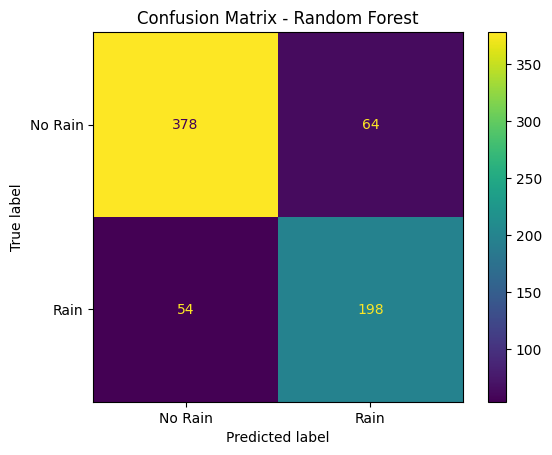

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# choose best model (example: Logistic Regression)
best_model = RandomForestClassifier(random_state=42)
best_model.fit(X_train_scaled,y_train)

# predictions
y_pred = best_model.predict(X_test_scaled)

# confusion matrix
cm = confusion_matrix(y_test, y_pred)

# display
disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=["No Rain","Rain"])
disp.plot()

plt.title("Confusion Matrix - Random Forest")
plt.show()

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test,y_pred, target_names=['NO Rain','Rain']))

              precision    recall  f1-score   support

     NO Rain       0.88      0.86      0.86       442
        Rain       0.76      0.79      0.77       252

    accuracy                           0.83       694
   macro avg       0.82      0.82      0.82       694
weighted avg       0.83      0.83      0.83       694



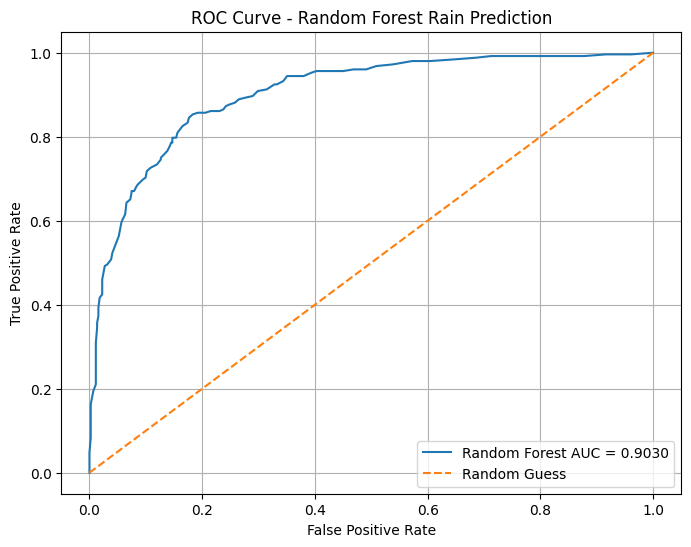

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Best model
best_model = RandomForestClassifier(random_state=42)
best_model.fit(X_train_scaled, y_train)

# Probability of class 1: Rain
y_prob = best_model.predict_proba(X_test_scaled)[:, 1]

# ROC values
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"Random Forest AUC = {auc_score:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random Guess")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest Rain Prediction")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

feature_importance

,Feature,Importance
5,humidity,0.206216
3,min_temp_C,0.108391
4,avg_temp_c,0.103137
8,sealevelpressure,0.102541
9,cloudcover,0.097749
11,solarradiation,0.075398
6,windgust,0.057699
1,month,0.052531
10,visibility,0.051209
2,max_temp_C,0.044721


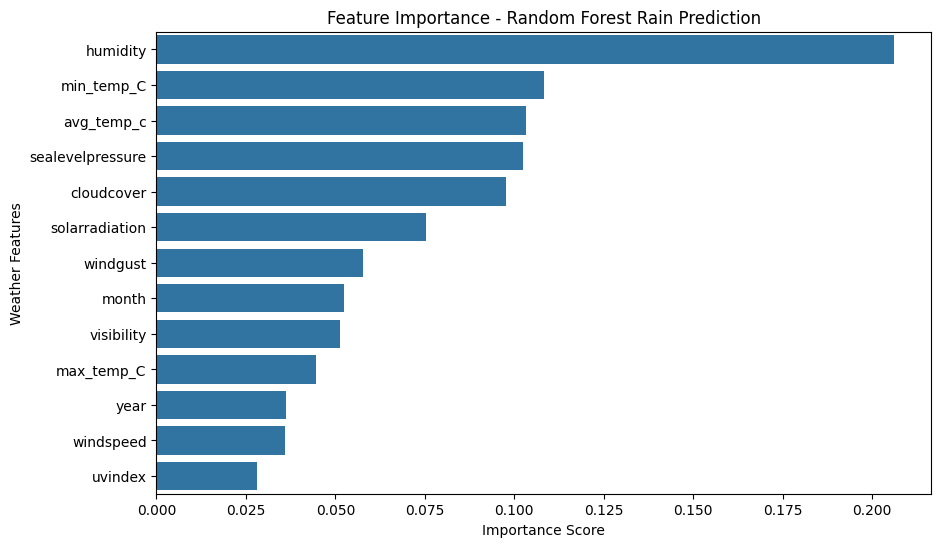

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance - Random Forest Rain Prediction")
plt.xlabel("Importance Score")
plt.ylabel("Weather Features")
plt.show()

After removing precipprob from the input features, humidity became the most important predictor of rainfall in Kathmandu. This shows that the model is no longer depending on direct precipitation probability and is instead learning from natural weather conditions. Minimum temperature, average temperature, sea level pressure, cloud cover, and solar radiation also contributed strongly to the prediction. These variables are logically related to rainfall because rain is influenced by moisture, temperature changes, cloud formation, and atmospheric pressure.

In [ ]:
df.head(1)

,year,month,max_temp_C,min_temp_C,avg_temp_c,humidity,precipprob,windgust,windspeed,sealevelpressure,cloudcover,visibility,solarradiation,uvindex,precipitation,rain
0,2015,1,15.94,3.94,10.0,74.7,100,11.2,5.8,1020.4,79.1,2.4,96.6,4,0.8,1


In [ ]:
df.columns

Index(['year', 'month', 'max_temp_C', 'min_temp_C', 'avg_temp_c', 'humidity',
       'precipprob', 'windgust', 'windspeed', 'sealevelpressure', 'cloudcover',
       'visibility', 'solarradiation', 'uvindex', 'precipitation', 'rain'],
      dtype='object')

In [ ]:
df.describe()

,year,month,max_temp_C,min_temp_C,avg_temp_c,humidity,precipprob,windgust,windspeed,sealevelpressure,cloudcover,visibility,solarradiation,uvindex,precipitation,rain
count,3468.000000,3468.000000,3468.000000,3468.000000,3468.000000,3468.000000,3468.000000,3468.000000,3468.000000,3468.000000,3468.000000,3468.000000,3468.000000,3468.000000,3468.000000,3468.000000
mean,2020.209919,6.365917,24.487621,13.992676,18.547552,75.141984,38.437140,17.471943,11.262197,1015.438379,47.204123,4.060986,185.324913,6.890715,4.088041,0.392445
std,2.837650,3.446432,4.327712,6.103337,5.081346,11.479143,48.651647,4.169347,5.879100,4.398764,24.038376,1.602044,58.836834,1.781841,10.769362,0.488365
min,2015.000000,1.000000,8.940000,0.060000,6.670000,25.200000,0.000000,4.700000,3.400000,1001.300000,18.800000,1.400000,0.000000,0.000000,0.000000,0.000000
25%,2018.000000,3.000000,20.940000,8.940000,13.985000,69.400000,0.000000,15.000000,9.200000,1012.100000,25.000000,3.600000,149.875000,6.000000,0.000000,0.000000
50%,2020.000000,6.000000,24.940000,14.940000,19.780000,76.200000,0.000000,16.600000,10.300000,1015.800000,36.500000,4.100000,182.400000,7.000000,0.000000,0.000000
75%,2023.000000,9.000000,27.940000,19.940000,23.110000,83.300000,100.000000,19.000000,12.800000,1018.900000,70.100000,4.500000,224.000000,8.000000,2.422300,1.000000
max,2025.000000,12.000000,38.940000,23.940000,27.220000,100.000000,100.000000,53.000000,165.800000,1025.800000,97.000000,88.600000,340.700000,10.000000,164.300000,1.000000


In [ ]:
df.dtypes

year                  int64
month                 int64
max_temp_C          float64
min_temp_C          float64
avg_temp_c          float64
humidity            float64
precipprob            int64
windgust            float64
windspeed           float64
sealevelpressure    float64
cloudcover          float64
visibility          float64
solarradiation      float64
uvindex               int64
precipitation       float64
rain                  int64
dtype: object

In [ ]:
# Calculate average weather values for month 5
month_5_avg = df[df["month"] == 5][X.columns].mean()

# Convert Series to DataFrame
future_month_5 = pd.DataFrame([month_5_avg])

# Set future year and month
future_month_5["year"] = 2026
future_month_5["month"] = 5

# Keep same column order as training data
future_month_5 = future_month_5[X.columns]

future_month_5

,year,month,max_temp_C,min_temp_C,avg_temp_c,humidity,windgust,windspeed,sealevelpressure,cloudcover,visibility,solarradiation,uvindex
0,2026,5,27.348323,17.130161,21.76071,72.108065,19.511935,12.364194,1013.276129,51.391935,4.333548,240.781935,8.151613


In [ ]:
future_month_5_scaled = scaler.transform(future_month_5)

prediction = best_model.predict(future_month_5_scaled)
probability = best_model.predict_proba(future_month_5_scaled)[:, 1]

if prediction[0] == 1:
    print(f"Rain expected for average May weather conditions. Probability: {probability[0] * 100:.2f}%")
else:
    print(f"No rain expected for average May weather conditions. Probability: {probability[0] * 100:.2f}%")

Rain expected for average May weather conditions. Probability: 58.00%
